#Data Science Project 2 — Supervised Learning (Fraud Detection Pipeline)

#Dataset: Credit Card Transactions (creditcard.csv — Kaggle standard, 284,807 transactions)

Libraries: NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn, Imbalanced-learn (imblearn)

In this notebook, we will:

1.Explore a highly imbalanced fraud dataset (EDA).

2.Split the data into train/test sets (before applying SMOTE to prevent data leakage).

3.Balance only the training data using SMOTE (inside an imblearn Pipeline).

4.Train Logistic Regression and Random Forest models.

5.Tune hyperparameters using GridSearchCV.

6.Discard Accuracy and evaluate models using Precision, Recall, F1-Score, and ROC-AUC.

**Batch: 2026 | DecodeLabs Industrial Training Kit**

## Step 0: Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
# imblearn: production-standard pipeline that applies resampling ONLY on training folds
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## Step 1: Upload & Load Dataset.

In [5]:
from google.colab import files
uploaded = files.upload()  # yahan creditcard.csv select karo

Saving creditcard.csv to creditcard.csv


In [8]:
df = pd.read_csv('creditcard.csv')
print("Original shape:", df.shape)
df.head()

Original shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#Speed Optimization: Stratified Subsample
#Running SMOTE + GridSearchCV on the full dataset (284,807 rows) can be very slow.

#Therefore, we take a stratified sample — this preserves the original class ratio (~0.17% fraud) so the reality of the imbalance doesn't change.

#Set SAMPLE_SIZE = None if you want to run it on the entire dataset.

In [11]:
SAMPLE_SIZE = 100000   # None = poora dataset use karo (slow)
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df, _ = train_test_split(
        df, train_size=SAMPLE_SIZE, random_state=42, stratify=df['Class']
    )
    df = df.reset_index(drop=True)
print("Working shape:", df.shape)
print("Fraud count:", df['Class'].sum(), f"({df['Class'].mean()*100:.3f}%)")

Working shape: (100000, 31)
Fraud count: 173 (0.173%)


## Step 2: Initial Inspection

In [14]:
print(df.info())
print()
print("Missing values:")
print(df.isnull().sum().sum(), "total missing values")
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    100000 non-null  float64
 1   V1      100000 non-null  float64
 2   V2      100000 non-null  float64
 3   V3      100000 non-null  float64
 4   V4      100000 non-null  float64
 5   V5      100000 non-null  float64
 6   V6      100000 non-null  float64
 7   V7      100000 non-null  float64
 8   V8      100000 non-null  float64
 9   V9      100000 non-null  float64
 10  V10     100000 non-null  float64
 11  V11     100000 non-null  float64
 12  V12     100000 non-null  float64
 13  V13     100000 non-null  float64
 14  V14     100000 non-null  float64
 15  V15     100000 non-null  float64
 16  V16     100000 non-null  float64
 17  V17     100000 non-null  float64
 18  V18     100000 non-null  float64
 19  V19     100000 non-null  float64
 20  V20     100000 non-null  float64
 21  V21     100

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,94911.67959,0.004615,-0.000428,-0.003030,0.004610,0.000817,-0.000442,-0.004522,-0.001054,0.008061,...,-0.003537,-0.000057,0.002273,-0.000516,-0.002809,0.000883,0.001732,0.000215,87.739974,0.001730
std,47447.66501,1.959589,1.641825,1.520997,1.414078,1.400446,1.340881,1.274387,1.210988,1.101574,...,0.745633,0.725225,0.616135,0.605315,0.520854,0.482372,0.409035,0.304861,251.353119,0.041557
min,0.00000,-46.855047,-60.464618,-48.325589,-5.560118,-113.743307,-21.929312,-43.557242,-73.216718,-13.320155,...,-34.830382,-9.499423,-30.269720,-2.836627,-7.081325,-2.604551,-9.543518,-15.430084,0.000000,0.000000
25%,54273.75000,-0.915429,-0.599388,-0.896968,-0.839514,-0.691595,-0.767388,-0.554504,-0.206895,-0.638003,...,-0.229067,-0.545856,-0.161368,-0.356239,-0.317995,-0.327039,-0.070327,-0.052740,5.830000,0.000000
50%,84949.00000,0.026905,0.062768,0.181160,-0.017308,-0.054628,-0.274670,0.039460,0.023548,-0.044612,...,-0.030417,0.004925,-0.010197,0.041104,0.015115,-0.050438,0.001453,0.011196,22.100000,0.000000
75%,139307.25000,1.316380,0.803593,1.022399,0.746288,0.612185,0.393125,0.570687,0.325915,0.606829,...,0.183928,0.524719,0.148670,0.438600,0.346889,0.240348,0.091806,0.077814,77.000000,0.000000
max,172792.00000,2.446505,22.057729,4.101716,16.875344,32.911462,73.301626,120.589494,20.007208,10.370658,...,27.202839,10.503090,22.083545,4.584549,6.070850,3.517346,31.612198,15.870474,25691.160000,1.000000


## Step 3: The Reality of the Class Imbalance
In fraud detection datasets, legitimate transactions far outnumber fraudulent ones.

Here we examine the exact imbalance — as shown in the presentation: ~99.83% legitimate vs ~0.17% fraud.

Class counts:
 Class
0    99827
1      173
Name: count, dtype: int64

Class percentage:
 Class
0    99.827
1     0.173
Name: proportion, dtype: float64


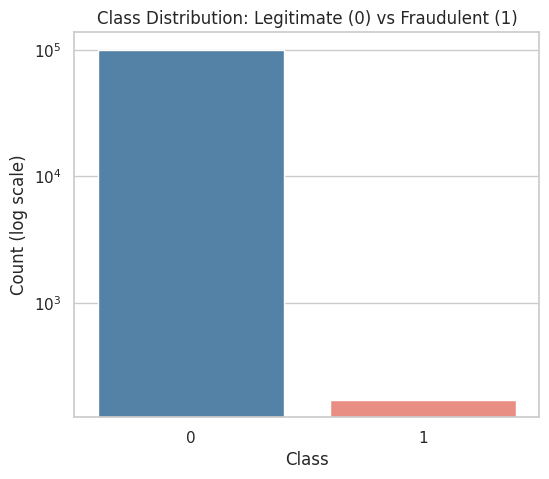

In [18]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print("Class counts:\n", class_counts)
print("\nClass percentage:\n", class_pct)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Class', hue='Class', palette=['steelblue', 'salmon'], legend=False)
plt.title('Class Distribution: Legitimate (0) vs Fraudulent (1)')
plt.yscale('log')  # log scale kyunki imbalance itna zyada hai ke normal scale pe fraud bar nazar hi nahi aayega
plt.ylabel('Count (log scale)')
plt.show()

Why "Accuracy" Is a Trap
If a model predicts "Legitimate" for every single transaction, it would still achieve ~99.83% accuracy — but it wouldn't catch a single fraud case (zero recall). Therefore, we discard Accuracy and focus on Precision, Recall, and ROC-AUC instead.

**Step 4:** Feature & Target Separation + Train/Test Split
CRITICAL: Split first, then apply SMOTE — and apply it ONLY to the training fold.

If SMOTE is applied before splitting, synthetic data will leak into the test set (Data Leakage Catastrophe — as warned in the presentation).

In [20]:
X = df.drop(columns=['Class'])
y = df['Class']
# Stratified split taake train aur test dono mein original class ratio preserve rahe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Fraud ratio:", y_train.mean())
print("Test shape :", X_test.shape, " Fraud ratio:", y_test.mean())

Train shape: (80000, 30)  Fraud ratio: 0.001725
Test shape : (20000, 30)  Fraud ratio: 0.00175


**Step 5:** Building Leak-Free Pipelines (imblearn.Pipeline)
Logistic Regression requires a StandardScaler (scale-sensitive), while Random Forest does not (scale-invariant, tree-based splits).

SMOTE fit_resample applies ONLY to the training data — imblearn's Pipeline automatically handles this inside each cross-validation fold, ensuring it never touches the validation or test fold.

In [24]:
# Pipeline 1: Logistic Regression (scaler zaroori hai)
pipeline_lr = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline 2: Random Forest (scaler ki zarurat nahi, tree-based hai)
pipeline_rf = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=1))
])

**Step 6:** Hyperparameter Tuning with GridSearchCV
GridSearchCV, combined with StratifiedKFold, safely re-applies SMOTE inside each fold — guaranteeing zero leakage during hyperparameter tuning as well.

In [27]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# Logistic Regression hyperparameter grid
param_grid_lr = {
    'smote__k_neighbors': [5],
    'classifier__C': [0.1, 1.0]
}
grid_lr = GridSearchCV(
    pipeline_lr, param_grid_lr, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)
print("Best LR params:", grid_lr.best_params_)
print("Best LR CV ROC-AUC:", grid_lr.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best LR params: {'classifier__C': 0.1, 'smote__k_neighbors': 5}
Best LR CV ROC-AUC: 0.9742433715413471


In [29]:
# Random Forest hyperparameter grid
param_grid_rf = {
    'smote__k_neighbors': [5],
    'classifier__max_depth': [10, 20],
    'classifier__n_estimators': [50]
}
grid_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print("Best RF params:", grid_rf.best_params_)
print("Best RF CV ROC-AUC:", grid_rf.best_score_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best RF params: {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'smote__k_neighbors': 5}
Best RF CV ROC-AUC: 0.9618801470928137


**Step 7:** Final Evaluation on the Untouched Test Set
Here we IGNORE Accuracy. We only evaluate Precision, Recall, F1-Score, and ROC-AUC — as these metrics show how many frauds the model catches and how many false alarms it generates.

In [31]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"===== {name} ===telek==")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
    return y_pred, y_proba

lr_pred, lr_proba = evaluate_model(grid_lr.best_estimator_, X_test, y_test, "Logistic Regression")
rf_pred, rf_proba = evaluate_model(grid_rf.best_estimator_, X_test, y_test, "Random Forest")

===== Logistic Regression ===telek==
Precision : 0.0625
Recall    : 0.8000
F1-Score  : 0.1159
ROC-AUC   : 0.9467

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     19965
       Fraud       0.06      0.80      0.12        35

    accuracy                           0.98     20000
   macro avg       0.53      0.89      0.55     20000
weighted avg       1.00      0.98      0.99     20000

===== Random Forest ===telek==
Precision : 0.7368
Recall    : 0.8000
F1-Score  : 0.7671
ROC-AUC   : 0.9559

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     19965
       Fraud       0.74      0.80      0.77        35

    accuracy                           1.00     20000
   macro avg       0.87      0.90      0.88     20000
weighted avg       1.00      1.00      1.00     20000



### Confusion Matrices

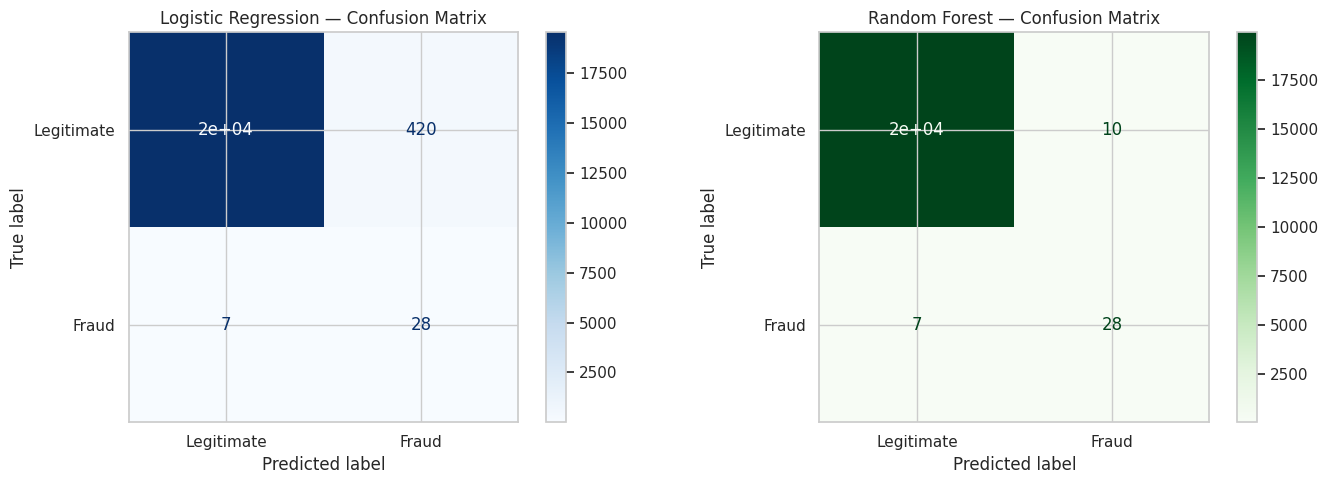

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, display_labels=['Legitimate', 'Fraud'], cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=['Legitimate', 'Fraud'], cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### ROC Curves Comparison

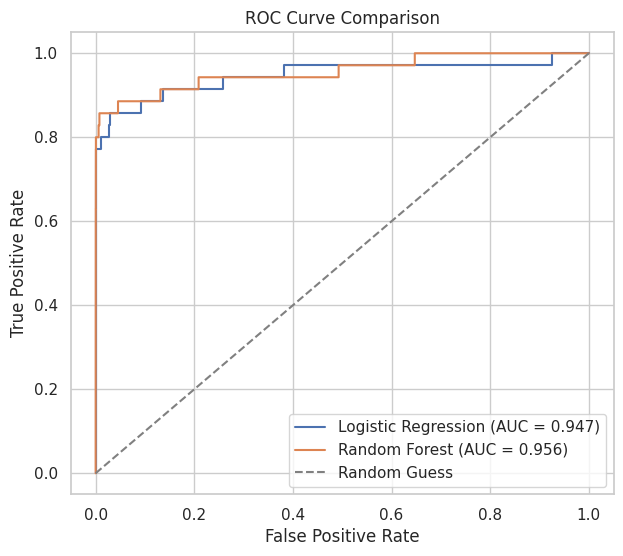

In [35]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**Step 8:** Model Selection
Compare Precision, Recall, and ROC-AUC across both models to choose the best one.

In fraud detection, Recall is often prioritized (missing a fraud is much more costly than raising a false alarm) — but depending on the business context, F1-Score or ROC-AUC can also be key deciding factors.

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, rf_pred)],
    'Recall': [recall_score(y_test, lr_pred), recall_score(y_test, rf_pred)],
    'F1-Score': [f1_score(y_test, lr_pred), f1_score(y_test, rf_pred)],
    'ROC-AUC': [roc_auc_score(y_test, lr_proba), roc_auc_score(y_test, rf_proba)]
})
results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.062500,0.8,0.115942,0.946677
1,Random Forest,0.736842,0.8,0.767123,0.955926


## Step 9: Save Best Model

In [39]:
import joblib

best_model = grid_rf.best_estimator_ if roc_auc_score(y_test, rf_proba) > roc_auc_score(y_test, lr_proba) else grid_lr.best_estimator_

joblib.dump(best_model, 'fraud_detection_best_model.pkl')

from google.colab import files
files.download('fraud_detection_best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Conclusion**
**In this notebook, we:**

Identified and visualized extreme class imbalance (99.83% vs 0.17%).

Performed train/test split BEFORE SMOTE to prevent data leakage.

Used imblearn Pipeline to ensure SMOTE is applied only on training folds (even within cross-validation).

Trained both Logistic Regression (scaled) and Random Forest (unscaled).

Tuned hyperparameters using GridSearchCV with ROC-AUC as the evaluation metric.

Discarded Accuracy and evaluated performance using Precision, Recall, F1-Score, and ROC-AUC.

Saved the best model for deployment.

This pipeline serves as a foundation for production-grade fraud detection — leak-free and properly evaluated.